# DINOv2-Small U1 pseudo-label generation on ACDC train

This notebook uses the best source-only `DINOv2 E3` checkpoint as a teacher to generate confidence-filtered pseudo-labels for `ACDC train`.
It:
- mounts Google Drive,
- unpacks `ACDC rgb`,
- loads the `DINOv2 E3` teacher,
- predicts pseudo-labels with `tau = 0.90`,
- saves masks with low-confidence pixels set to `255`,
- logs per-condition keep-ratio statistics to ClearML.


In [ ]:
!pip install -q albumentations torchmetrics pytorch-lightning clearml python-dotenv gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 95.7 MB/s eta 0:00:00


In [ ]:
import os
import json
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from clearml import Task
from google.colab import drive, userdata


In [ ]:
CONFIG = {
    "project_name": "Segmentation_Urban_Scene_CourseWork",
    "task_name": "DinoV2_Small_U1_PseudoLabels_ACDC_Train",
    "drive_root": "/content/drive/MyDrive",
    "teacher_weights_rel_path": "weights/dinov2-small-E3-cityscapes-epoch=44-val_miou=0.6406.ckpt",
    "acdc_zips": [
        "rgb_anon_trainvaltest.zip",
    ],
    "data_dir": "/content/data/acdc",
    "split": "train",
    "conditions": ["fog", "night", "rain", "snow"],
    "model_name": "dinov2_vits14",
    "num_classes": 19,
    "image_size": (518, 1022),
    "batch_size": 8,
    "num_workers": 2,
    "confidence_threshold": 0.90,
    "pseudo_labels_rel_path": "pseudo_labels/acdc/dinov2_e3_u1_round1",
    "preview_count": 6,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

torch.set_float32_matmul_precision("medium")

os.environ["CLEARML_API_ACCESS_KEY"] = userdata.get("CLEARML_API_ACCESS_KEY")
os.environ["CLEARML_API_SECRET_KEY"] = userdata.get("CLEARML_API_SECRET_KEY")

task = Task.init(
    project_name=CONFIG["project_name"],
    task_name=CONFIG["task_name"],
    output_uri=False,
)
task.connect(CONFIG)

print(f"Using device: {CONFIG['device']}")


ClearML Task: created new task id=9459f975fb7f4453b4a28ea96f4b1588


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-03-28 19:23:03,534 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/588d5d925230490b9f98b1007b4c7fa0/experiments/9459f975fb7f4453b4a28ea96f4b1588/output/log
Using device: cuda


In [ ]:
drive.mount("/content/drive")

Path(CONFIG["data_dir"]).mkdir(parents=True, exist_ok=True)

for zip_name in CONFIG["acdc_zips"]:
    zip_path = Path(CONFIG["drive_root"]) / zip_name
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip file not found: {zip_path}")

    print(f"Unpacking {zip_path} -> {CONFIG['data_dir']}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(CONFIG["data_dir"])

teacher_weights_path = Path(CONFIG["drive_root"]) / CONFIG["teacher_weights_rel_path"]
if not teacher_weights_path.exists():
    raise FileNotFoundError(f"Teacher checkpoint not found: {teacher_weights_path}")

output_root = Path(CONFIG["drive_root"]) / CONFIG["pseudo_labels_rel_path"]
output_root.mkdir(parents=True, exist_ok=True)

print(f"Teacher checkpoint: {teacher_weights_path}")
print(f"Pseudo-label output root: {output_root}")


Mounted at /content/drive
Unpacking /content/drive/MyDrive/rgb_anon_trainvaltest.zip -> /content/data/acdc
Teacher checkpoint: /content/drive/MyDrive/weights/dinov2-small-E3-cityscapes-epoch=44-val_miou=0.6406.ckpt
Pseudo-label output root: /content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1


In [ ]:
class ACDCUnlabeledDataset(Dataset):
    def __init__(self, root_dir, split="train", conditions=None, augmentation=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.conditions = conditions or ["fog", "night", "rain", "snow"]
        self.augmentation = augmentation
        self.items = []

        for condition in self.conditions:
            rgb_root = self.root_dir / "rgb_anon" / condition / split
            if not rgb_root.exists():
                print(f"Skip missing split folder: {condition}/{split}")
                continue

            for image_path in sorted(rgb_root.rglob("*_rgb_anon.png")):
                rel = image_path.relative_to(rgb_root)
                self.items.append(
                    {
                        "image": str(image_path),
                        "condition": condition,
                        "relative_parent": "" if str(rel.parent) == "." else str(rel.parent),
                        "file_name": image_path.name,
                        "stem": image_path.stem,
                    }
                )

        if len(self.items) == 0:
            raise RuntimeError("No ACDC train images found. Check dataset path and split.")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sample = self.items[idx]
        image = cv2.imread(sample["image"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.augmentation is not None:
            transformed = self.augmentation(image=image)
            image = transformed["image"]

        return {
            "image": image,
            "condition": sample["condition"],
            "relative_parent": sample["relative_parent"],
            "file_name": sample["file_name"],
            "stem": sample["stem"],
        }


In [ ]:
valid_transform = A.Compose([
    A.Resize(height=CONFIG["image_size"][0], width=CONFIG["image_size"][1]),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

dataset = ACDCUnlabeledDataset(
    root_dir=CONFIG["data_dir"],
    split=CONFIG["split"],
    conditions=CONFIG["conditions"],
    augmentation=valid_transform,
)

loader = DataLoader(
    dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

print(f"ACDC train samples: {len(dataset)}")
display(pd.DataFrame(dataset.items)["condition"].value_counts().sort_index().rename("images").to_frame())


ACDC train samples: 1600


,images
condition,
fog,400
night,400
rain,400
snow,400


In [ ]:
class LinearSegmentationHead(nn.Module):
    def __init__(self, embed_dim=384, num_classes=19, patch_size=14):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_classes = num_classes
        self.patch_size = patch_size
        self.linear = nn.Conv2d(embed_dim, num_classes, kernel_size=1)

    def forward(self, x, h, w):
        batch_size, n_tokens, channels = x.shape
        patch_h = h // self.patch_size
        patch_w = w // self.patch_size
        x = x.reshape(batch_size, patch_h, patch_w, channels).permute(0, 3, 1, 2)
        x = self.linear(x)
        x = F.interpolate(x, size=(h, w), mode="bilinear", align_corners=False)
        return x


class DinoV2SegmentationModel(nn.Module):
    def __init__(self, model_name="dinov2_vits14", num_classes=19):
        super().__init__()
        self.backbone = torch.hub.load("facebookresearch/dinov2", model_name)
        self.embed_dim = 384
        self.patch_size = 14
        self.segmentation_head = LinearSegmentationHead(
            embed_dim=self.embed_dim,
            num_classes=num_classes,
            patch_size=self.patch_size,
        )

    def forward(self, x):
        _, _, h, w = x.shape
        features = self.backbone.forward_features(x)
        patch_features = features["x_norm_patchtokens"]
        logits = self.segmentation_head(patch_features, h, w)
        return logits


def load_teacher_checkpoint(model, ckpt_path, device):
    checkpoint = torch.load(ckpt_path, map_location=device)
    state_dict = checkpoint.get("state_dict", checkpoint)

    model_state = {}
    for key, value in state_dict.items():
        if key.startswith("backbone.") or key.startswith("segmentation_head."):
            model_state[key] = value

    missing, unexpected = model.load_state_dict(model_state, strict=False)
    print(f"Missing keys: {len(missing)}")
    print(f"Unexpected keys: {len(unexpected)}")

    model.to(device)
    model.eval()
    return model


teacher = DinoV2SegmentationModel(
    model_name=CONFIG["model_name"],
    num_classes=CONFIG["num_classes"],
)
teacher = load_teacher_checkpoint(teacher, str(teacher_weights_path), CONFIG["device"])


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning:

xFormers is not available (SwiGLU)

/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning:

xFormers is not available (Attention)

/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning:

xFormers is not available (Block)



Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 203MB/s]


2026-03-28 19:29:53,883 - clearml.model - INFO - Selected model id: 096af8490ce44af1b6986ef1b35ef075
2026-03-28 19:30:05,238 - clearml.model - INFO - Selected model id: 3607601e277f48e0a32bd60c92c4c58d
Missing keys: 0
Unexpected keys: 0


In [ ]:
@torch.no_grad()
def generate_pseudo_labels(model, dataloader, output_root, threshold, device):
    logger = task.get_logger()
    stats = []
    preview_items = []

    for batch in dataloader:
        images = batch["image"].to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        confidences, preds = probs.max(dim=1)

        pseudo_masks = preds.to(torch.uint8)
        pseudo_masks[confidences < threshold] = 255

        for idx in range(images.shape[0]):
            condition = batch["condition"][idx]
            relative_parent = batch["relative_parent"][idx]
            file_name = batch["file_name"][idx]
            stem = batch["stem"][idx]

            save_dir = output_root / condition / CONFIG["split"]
            if relative_parent:
                save_dir = save_dir / relative_parent
            save_dir.mkdir(parents=True, exist_ok=True)

            mask_name = file_name.replace("_rgb_anon.png", "_gt_labelTrainIds.png")
            mask_path = save_dir / mask_name
            pseudo_mask = pseudo_masks[idx].detach().cpu().numpy()
            cv2.imwrite(str(mask_path), pseudo_mask)

            confidence_map = confidences[idx].detach().cpu()
            keep_mask = torch.from_numpy(pseudo_mask != 255)
            keep_ratio = float(keep_mask.float().mean().item())
            mean_confidence = float(confidence_map.mean().item())
            mean_confidence_kept = float(confidence_map[keep_mask].mean().item()) if keep_mask.any().item() else 0.0

            stats.append(
                {
                    "condition": condition,
                    "stem": stem,
                    "pseudo_mask_path": str(mask_path),
                    "keep_ratio": keep_ratio,
                    "mean_confidence": mean_confidence,
                    "mean_confidence_kept": mean_confidence_kept,
                }
            )

            if len(preview_items) < CONFIG["preview_count"]:
                preview_items.append(
                    {
                        "image": images[idx].detach().cpu(),
                        "pseudo_mask": pseudo_masks[idx].detach().cpu(),
                        "confidence_map": confidence_map,
                        "condition": condition,
                        "stem": stem,
                    }
                )

    stats_df = pd.DataFrame(stats)
    summary_df = (
        stats_df.groupby("condition", as_index=False)
        .agg(
            images=("stem", "count"),
            mean_keep_ratio=("keep_ratio", "mean"),
            mean_confidence=("mean_confidence", "mean"),
            mean_confidence_kept=("mean_confidence_kept", "mean"),
        )
        .sort_values("condition")
        .reset_index(drop=True)
    )

    stats_df.to_csv(output_root / "pseudo_label_stats.csv", index=False)
    summary_df.to_csv(output_root / "pseudo_label_summary.csv", index=False)
    with open(output_root / "pseudo_label_config.json", "w", encoding="utf-8") as handle:
        json.dump(CONFIG, handle, indent=2)

    logger.report_scalar(
        "pseudo_labels",
        "overall_keep_ratio",
        float(stats_df["keep_ratio"].mean()),
        iteration=0,
    )
    for _, row in summary_df.iterrows():
        logger.report_scalar(
            "pseudo_labels",
            f"keep_ratio_{row['condition']}",
            float(row["mean_keep_ratio"]),
            iteration=0,
        )

    return summary_df, stats_df, preview_items


summary_df, stats_df, preview_items = generate_pseudo_labels(
    teacher,
    loader,
    output_root=output_root,
    threshold=CONFIG["confidence_threshold"],
    device=CONFIG["device"],
)

print(f"Saved pseudo-labels to: {output_root}")
display(summary_df)
display(stats_df.head(10))


Saved pseudo-labels to: /content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1


,condition,images,mean_keep_ratio,mean_confidence,mean_confidence_kept
0,fog,400,0.829722,0.935042,0.992028
1,night,400,0.654314,0.873882,0.987073
2,rain,400,0.801784,0.926144,0.990589
3,snow,400,0.793336,0.924965,0.989676


,condition,stem,pseudo_mask_path,keep_ratio,mean_confidence,mean_confidence_kept
0,fog,GOPR0475_frame_000041_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000041_gt_labelTrainIds.png,0.822073,0.939142,0.990795
1,fog,GOPR0475_frame_000049_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000049_gt_labelTrainIds.png,0.930610,0.975941,0.995813
2,fog,GOPR0475_frame_000096_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000096_gt_labelTrainIds.png,0.823656,0.940452,0.990127
3,fog,GOPR0475_frame_000116_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000116_gt_labelTrainIds.png,0.756844,0.903384,0.990679
4,fog,GOPR0475_frame_000122_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000122_gt_labelTrainIds.png,0.902750,0.966496,0.994447
5,fog,GOPR0475_frame_000128_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000128_gt_labelTrainIds.png,0.890989,0.962195,0.993723
6,fog,GOPR0475_frame_000135_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000135_gt_labelTrainIds.png,0.765433,0.919870,0.987364
7,fog,GOPR0475_frame_000148_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000148_gt_labelTrainIds.png,0.661986,0.877394,0.987535
8,fog,GOPR0475_frame_000154_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000154_gt_labelTrainIds.png,0.780278,0.920734,0.990497
9,fog,GOPR0475_frame_000161_rgb_anon,/content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1/fog/train/GOPR0475/GOPR0475_frame_000161_gt_labelTrainIds.png,0.737969,0.907026,0.989916


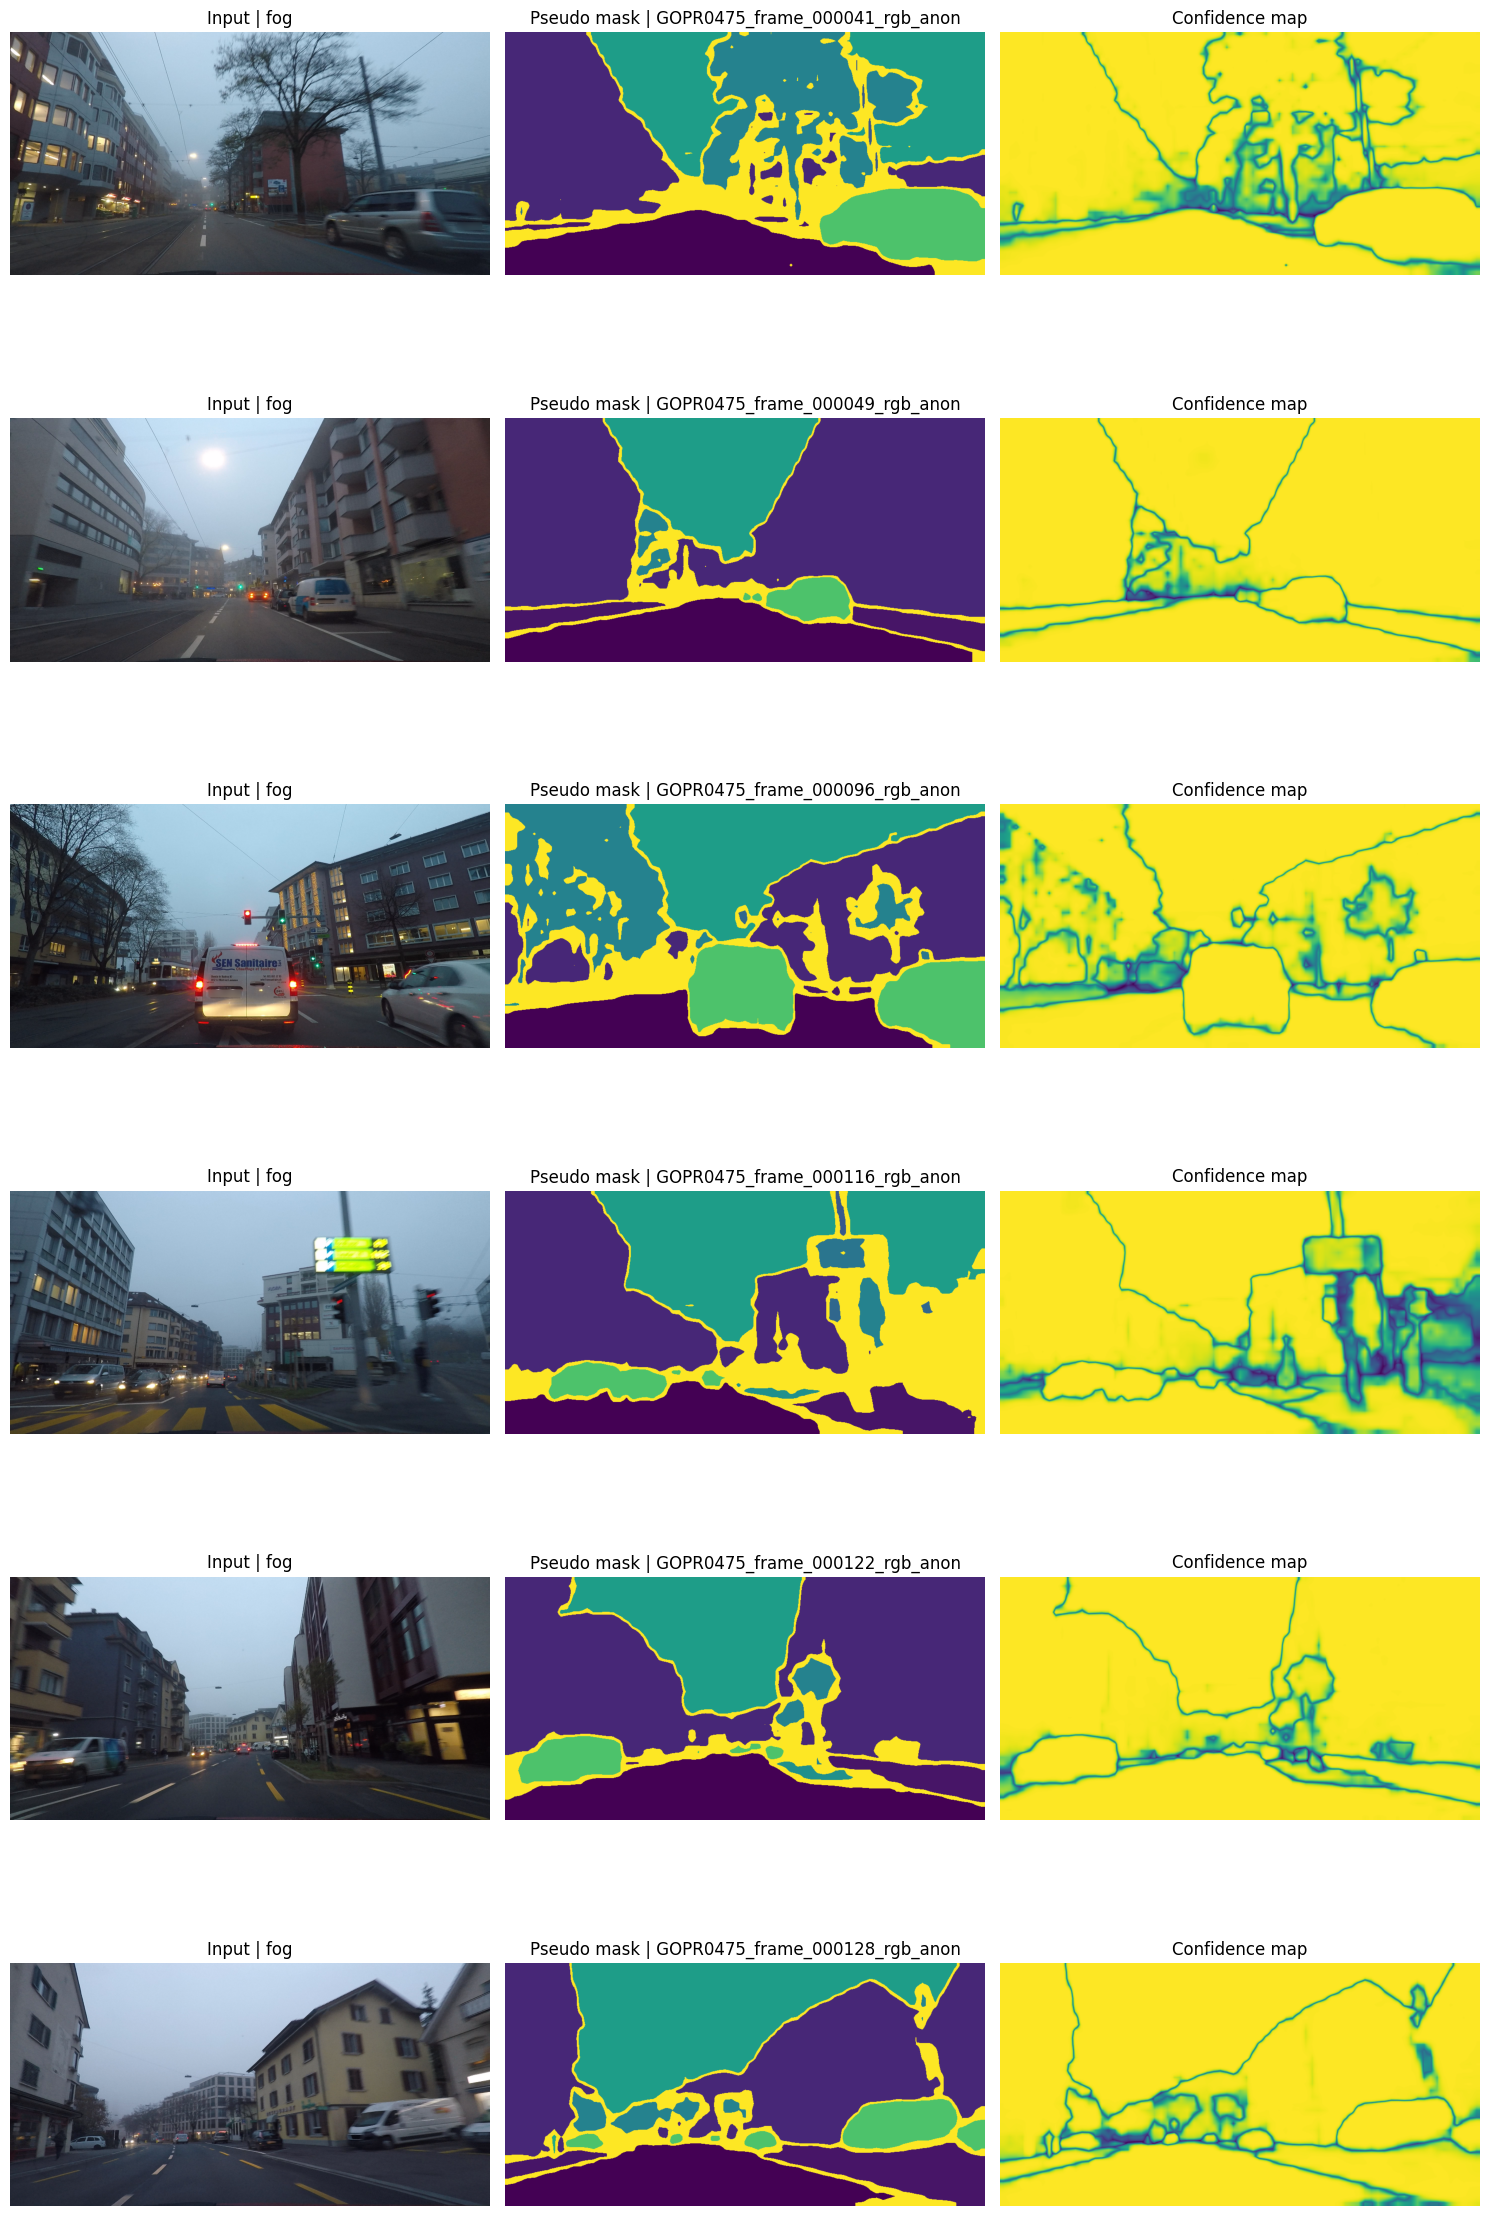

In [ ]:
def denormalize_for_display(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return torch.clamp(img, 0.0, 1.0).permute(1, 2, 0).numpy()


if len(preview_items) > 0:
    fig, axes = plt.subplots(len(preview_items), 3, figsize=(15, 4 * len(preview_items)))
    axes = np.atleast_2d(axes)

    for row_idx, item in enumerate(preview_items):
        axes[row_idx, 0].imshow(denormalize_for_display(item["image"]))
        axes[row_idx, 0].set_title(f"Input | {item['condition']}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(item["pseudo_mask"].numpy(), vmin=0, vmax=18)
        axes[row_idx, 1].set_title(f"Pseudo mask | {item['stem']}")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(item["confidence_map"].numpy(), cmap="viridis")
        axes[row_idx, 2].set_title("Confidence map")
        axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
task.close()